# FDS/IDS Assignment

## Load Data and Drop Duplicates

In [195]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

file_path = "data/UCMF.xls"
df = pd.read_excel(file_path)

print(f"Original Shape: {df.shape}")

df = df.drop_duplicates()
print(f"Drop duplicates shape: {df.shape}")

Original Shape: (17873, 21)
Drop duplicates shape: (17873, 21)


## Plot Dropped Function

In [196]:
import matplotlib.pyplot as plt

def plot_step(df, mask_removed, x_col, y_col, title, filename):
    df_in = df.copy()
    plt.figure(figsize=(10, 6))
    
    # Plot Kept
    kept = df_in[~mask_removed]
    plt.scatter(kept[x_col], kept[y_col], c='blue', alpha=0.3, s=10, label='Kept')
    
    # Plot Removed
    removed = df_in[mask_removed]
    plt.scatter(removed[x_col], removed[y_col], c='red', alpha=0.6, s=15, marker='x', label='Removed')
    
    plt.title(f"{title}\n({len(removed)} removed)")
    plt.xlabel('Age (Years)')
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

## Peso, Altura, Idade, IMC and Sexo

Age fixed shape: (16255, 23)
0         2.40
1         2.40
3         2.40
4        13.00
5         4.00
         ...  
17867     3.25
17868     2.90
17869     2.90
17870    15.20
17872    16.00
Name: Peso, Length: 16255, dtype: float64


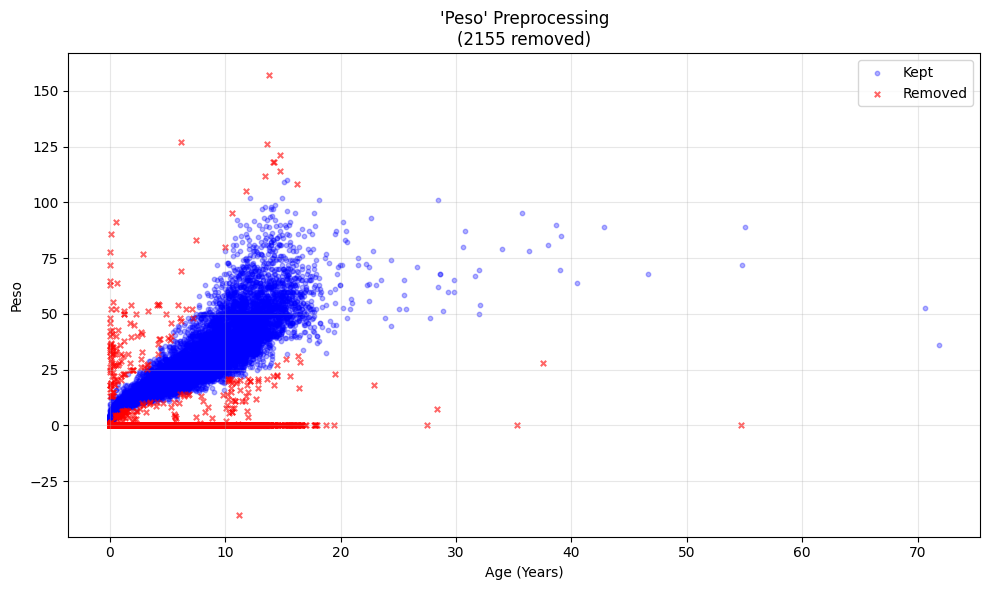

Peso age group outliers removed shape: (14100, 25)
Altura age group outliers removed shape: (14100, 25)


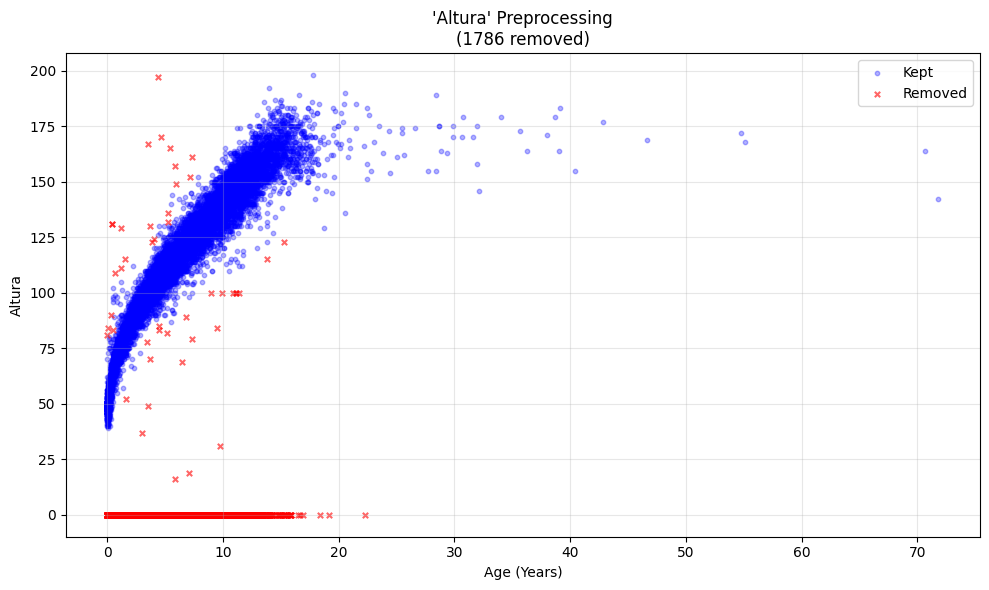

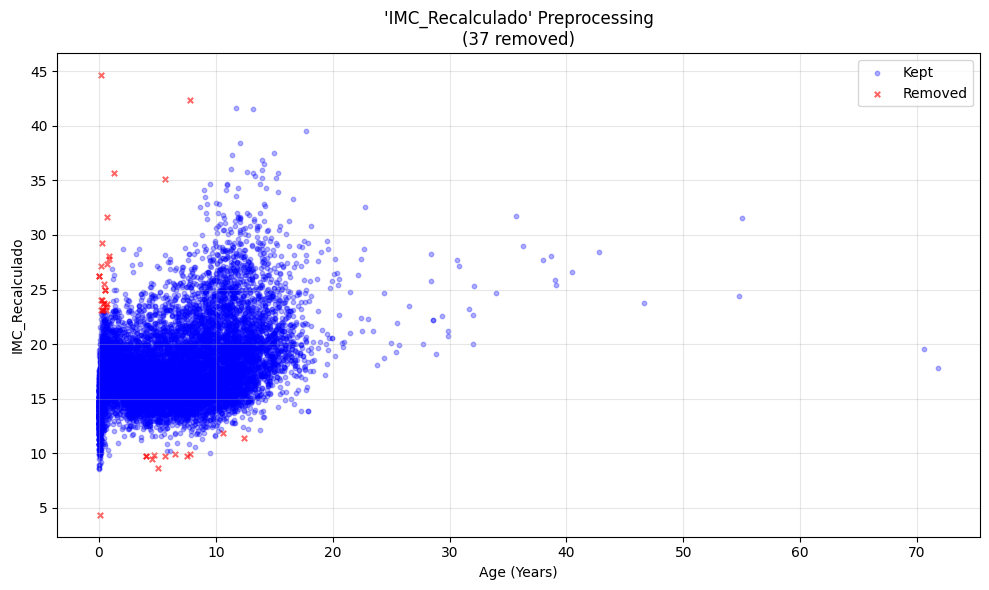

Final shape after IMC filtering: (12277, 26)
SEXO
M                6509
F                4764
Masculino         413
Indeterminado     366
Feminino          167
masculino          55
Name: count, dtype: int64
Final shape: (11908, 26)


In [197]:
import pandas as pd

# turn to numeric all weights, heights and ages, np.nan those you cannot
for col in ['Peso', 'IDADE', 'Altura']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# calculate age based on atendimento and DN
df['Idade_Calc'] = (pd.to_datetime(df['Atendimento'], dayfirst=True, format='%d/%m/%y', errors='coerce') - 
                    pd.to_datetime(df['DN'], dayfirst=True, format='%d/%m/%y', errors='coerce')).dt.days / 365.25

# if cases have small error or we don't have value, we trust in
# the calculated age, else, we use the values provided
error_condition = abs(df['Idade_Calc'] - df['IDADE']) > 1.0
df['Idade'] = np.where(error_condition | df['Idade_Calc'].isna(), df['IDADE'], df['Idade_Calc'])

# remove remaining invalid values
df = df[df['Idade'] >= 0]

print(f"Age fixed shape: {df.shape}")

# define filter to remove invalid values
peso_mask = (
    (df['Peso'] <= 0) |
    (df['Peso'] >= 250) |
    (df['Peso'].isna())
)

# ultra conservative weights chosen to account for people with diseases
# based on 1st percentile values from WHO (~3 SD), Extreme Low Birth Weight 
# newborn babies get "ignored" here
def get_min_viable_weight(age):
    if age < 1: return 1.5  # Premature/Newborn
    if age < 3: return 7.0  # Toddler
    if age < 6: return 10.0 # Young Child
    if age < 10: return 15.0 # School age
    if age < 14: return 22.0 # Pre-teen
    return 30.0 # Teen/Adult

# apply minimum weight filter
df['Min_Weight'] = df['Idade'].apply(get_min_viable_weight)
peso_mask |= df['Peso'] < df['Min_Weight']

# remove outliers by age group, use double the iqr for upper (to only target percentiles
# 97-99 of each age group, which are most likely to be errors) multiplier since
# we are in medical context and obesity is expected, only obvious errors removed
# Assymetric Ranges used because of average patient profile
df['Grupo_Idade'] = df['IDADE'].round()

groups_age = df.groupby('Grupo_Idade')['Peso']

Q1 = groups_age.transform(lambda x: x.quantile(0.25))
Q3 = groups_age.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

lower_bound = Q1 - 1.0 * IQR
upper_bound = Q3 + 3.0 * IQR
print(IQR)
peso_mask |= (df['Peso'] < lower_bound) | (df['Peso'] > upper_bound)

plot_step(df, peso_mask, "Idade", "Peso", "'Peso' Preprocessing", "peso_removal.png")

df = df[~peso_mask].copy()
print(f"Peso age group outliers removed shape: {df.shape}")

# remove nonesensical heights (less than 15cm and more than 250cm)
altura_mask = (
    (df['Altura'] < 15) |
    (df['Altura'] > 250) |
    (df['Altura'].isna())
) 

# same logic as above, value of 2.0 utilised for both upper and lower limit,
# a good meld between solving for outliers while maintaining variance in the populations
groups_altura = df.groupby('Grupo_Idade')['Altura']

Q1 = groups_altura.transform(lambda x: x.quantile(0.25))
Q3 = groups_altura.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

lower_bound = Q1 - 2.5 * IQR
upper_bound = Q3 + 2.5 * IQR

altura_mask |= ((df['Altura'] < lower_bound) | (df['Altura'] > upper_bound))
print(f"Altura age group outliers removed shape: {df.shape}")

plot_step(df, altura_mask, "Idade", "Altura", "'Altura' Preprocessing", "altura_removal.png")
df = df[~altura_mask].copy()

df['IMC_Recalculado'] = df['Peso'] / ((df['Altura'] / 100) ** 2)

# True for rows to remove
def get_imc_validity_mask(df):
    mask = pd.Series(False, index=df.index)
    
    # Infants (< 1 year): IMC 6-23
    mask |= (df['Idade'] < 1) & ((df['IMC_Recalculado'] < 6) | (df['IMC_Recalculado'] > 23))
    
    # Toddlers/Kids (1-10 years): IMC 10-35
    mask |= (df['Idade'] >= 1) & (df['Idade'] < 10) & (
        (df['IMC_Recalculado'] < 10) | (df['IMC_Recalculado'] > 35)
    )
    
    # Teens/Adults (10+ years): IMC 12-50
    mask |= (df['Idade'] >= 10) & (
        (df['IMC_Recalculado'] < 12) | (df['IMC_Recalculado'] > 50)
    )
    
    return mask

IMC_mask = get_imc_validity_mask(df)

plot_step(df, IMC_mask, "Idade", "IMC_Recalculado", "'IMC_Recalculado' Preprocessing", "imc_removal.png")
df = df[~IMC_mask].copy()

df['IMC'] = df['IMC_Recalculado']
print(f"Final shape after IMC filtering: {df.shape}")

print(df['SEXO'].value_counts())

# all possible gender mappings
sexo_map = {
    'M': 1, 'Masculino': 1, 'masculino': 1,
    'F': 0, 'f': 0, 'Feminino': 0, 'feminino': 0
}

# apply map, values not defined become np.nan
df['SEXO'] = df['SEXO'].map(sexo_map)

# drop nan
df = df.dropna(subset=['SEXO'])

print(f"Final shape: {df.shape}")

## Drop and Organize Columns

In [198]:
print(df.columns)

df = df.drop(columns=['ID', 'Atendimento', 'DN', 'IDADE', 'Convenio', 'Idade_Calc', 'IMC_Recalculado'])

Index(['ID', 'Peso', 'Altura', 'IMC', 'Atendimento', 'DN', 'IDADE', 'Convenio',
       'PULSOS', 'PA SISTOLICA', 'PA DIASTOLICA', 'PPA', 'NORMAL X ANORMAL',
       'B2', 'SOPRO', 'FC', 'HDA 1', 'HDA2', 'SEXO', 'MOTIVO1', 'MOTIVO2',
       'Idade_Calc', 'Idade', 'Min_Weight', 'Grupo_Idade', 'IMC_Recalculado'],
      dtype='object')


## PA Sistolica, PA Diastolica and FC

Shape after negative or null removal: (7091, 19)


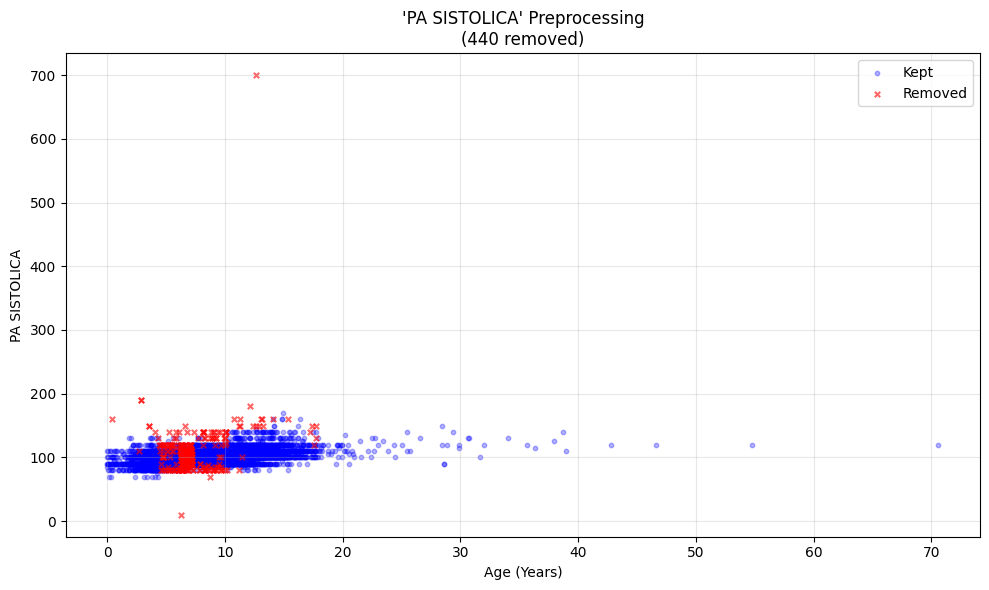

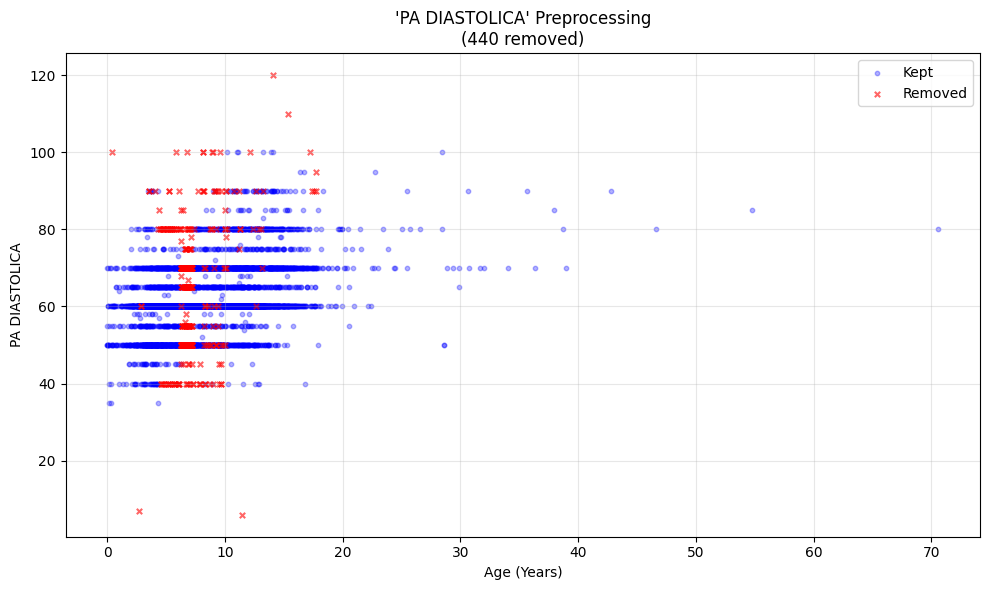

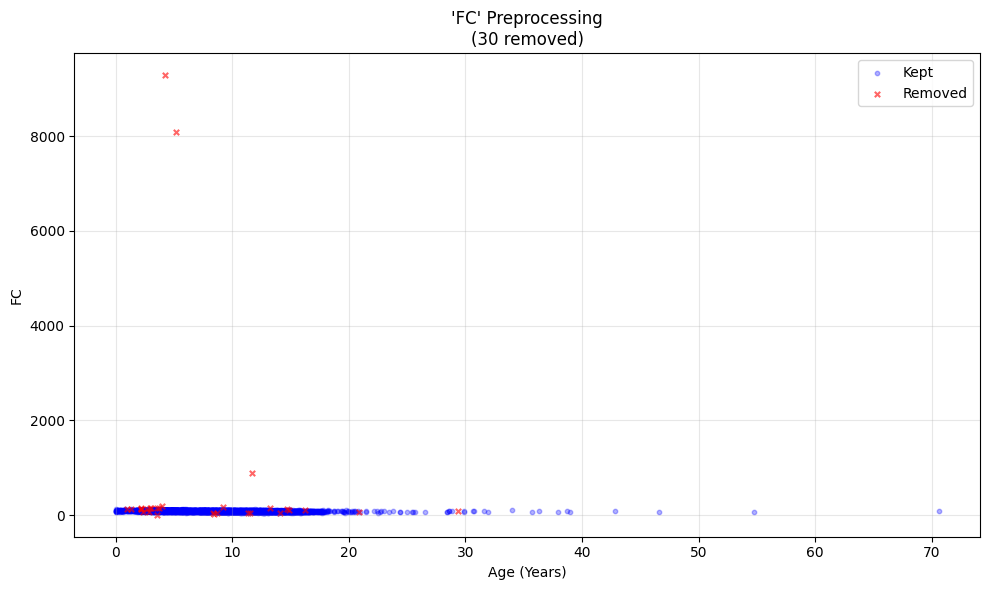

In [199]:
cols_vitals = ['PA SISTOLICA', 'PA DIASTOLICA', 'FC']
for col in cols_vitals:
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # negative/null values impossible for living beings
    df = df[df[col] > 0]

print(f"Shape after negative or null removal: {df.shape}")

bp_mask = pd.Series(False, index=df.index)

# cannot have inverted bp or very close
bp_mask |= (df['PA DIASTOLICA'] > df['PA SISTOLICA'])
bp_mask |= ((df['PA SISTOLICA'] - df['PA DIASTOLICA']) < 10)

# hard medical limits for blood pressure
bp_mask |= (
    (df['PA SISTOLICA'] > 320) | (df['PA SISTOLICA'] < 40) |
    (df['PA DIASTOLICA'] > 200) | (df['PA DIASTOLICA'] < 20)
)

groups = df.groupby('Grupo_Idade')['PA SISTOLICA']
    
Q1 = groups.transform(lambda x: x.quantile(0.25))
Q3 = groups.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

# higher fluctuations possible here
lower = Q1 - 2.0 * IQR  # Allow lower drops (shock/hypotension)
upper = Q3 + 3.5 * IQR  # Allow massive spikes (hypertension/tachycardia)
    
bp_mask |= ((df['PA SISTOLICA'] < lower) | (df['PA SISTOLICA'] > upper))

groups = df.groupby('Grupo_Idade')['PA DIASTOLICA']
    
Q1 = groups.transform(lambda x: x.quantile(0.25))
Q3 = groups.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

# higher fluctuations possible here
lower = Q1 - 2.0 * IQR  # Allow lower drops (shock/hypotension)
upper = Q3 + 3.5 * IQR  # Allow massive spikes (hypertension/tachycardia)
    
bp_mask |= ((df['PA DIASTOLICA'] < lower) | (df['PA DIASTOLICA'] > upper))

plot_step(df, bp_mask, 'Idade', 'PA SISTOLICA', "'PA SISTOLICA' Preprocessing", "sist_removal.png")
plot_step(df, bp_mask, 'Idade', 'PA DIASTOLICA', "'PA DIASTOLICA' Preprocessing", "diast_removal.png")

df = df[~bp_mask].copy()

# hard coded heart frequency limits
fc_mask = (df['FC'] > 300) | (df['FC'] < 25)

groups = df.groupby('Grupo_Idade')['FC']
    
Q1 = groups.transform(lambda x: x.quantile(0.25))
Q3 = groups.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

# higher fluctuations possible here
lower = Q1 - 2.0 * IQR  # Allow lower drops (shock/hypotension)
upper = Q3 + 3.5 * IQR  # Allow massive spikes (hypertension/tachycardia)

fc_mask |= ((df['FC'] < lower) | (df['FC'] > upper))

plot_step(df, fc_mask, 'Idade', 'FC', "'FC' Preprocessing", "fc_removal.png")
df = df[~fc_mask].copy()

## PULSOS, PPA, B2, SOPRO, HDA and MOTIVO

In [ ]:
# unify all 'SOPRO' types
df['SOPRO'] = df['SOPRO'].str.lower().str.strip()

def multi_column_one_hot(df, prefix, cols_to_combine):
    """
    Creates binary columns for unique values found across multiple columns.
    Example: Combines HDA1 and HDA2 into HDA_Dispneia, HDA_Dor, etc.
    """
    # 1. Get all unique values across the specified columns
    unique_values = set()
    for col in cols_to_combine:
        unique_values.update(df[col].dropna().unique())
    
    # 2. Create a new binary column for each unique value
    for val in unique_values:
        # Create a clean column name (remove spaces/special chars)
        clean_name = str(val).replace(' ', '_').replace('/', '_').replace('-', '')
        col_name = f"{prefix}_{clean_name}"
        
        # Check if value exists in ANY of the target columns
        # result is 1 if present, 0 if not
        mask = df[cols_to_combine].apply(lambda x: val in x.values, axis=1)
        df[col_name] = mask.astype(int)
        
    # 3. Drop the original columns
    df = df.drop(columns=cols_to_combine)
    return df

# Apply to HDA
df = multi_column_one_hot(df, "HDA", ['HDA 1', 'HDA 2'])

# Apply to MOTIVO
# Note: MOTIVO has numbers (e.g., "5 - Parecer"). You might want to strip numbers first.
# Optional: Strip "15 - ", "6 - " from start of strings if you want cleaner names
for col in ['MOTIVO1', 'MOTIVO2']:
    df[col] = df[col].astype(str).str.replace(r'^\d+\s*-\s*', '', regex=True)

df = multi_column_one_hot(df, "MOTIVO", ['MOTIVO1', 'MOTIVO2'])

# Grouping rare PULSOS (avoid overfitting)
rare_pulsos = ['Femorais diminuidos', 'Diminuídos']
df.loc[df['PULSOS'].isin(rare_pulsos), 'PULSOS'] = 'Alterado'

# Grouping rare B2 (avoid overfitting)
df.loc[df['B2'] == 'Única', 'B2'] = 'Outro'

cols_to_encode = ['PULSOS', 'PPA', 'B2', 'SOPRO']

# drop_first=True prevents multicollinearity (keeps N-1 columns)
# If using Tree-based models (XGBoost/RandomForest), you can set drop_first=False
df = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode, drop_first=True, dtype=int)

print(f"Final shape for ML: {df.shape}")

PULSOS
Normais                6591
Outro                    10
Amplos                    7
Femorais diminuidos       5
Diminuídos                1
Name: count, dtype: int64
PPA
Normal                 5373
Não Calculado           379
Pre-Hipertensão PAD     195
Pre-Hipertensão PAS     170
HAS-2 PAS               121
HAS-1 PAS               121
HAS-1 PAD                70
HAS-2 PAD                36
Name: count, dtype: int64
B2
Normal           6431
Hiperfonética      65
Desdob fixo        60
Outro              55
Única               9
Name: count, dtype: int64
SOPRO
ausente                   4578
sistólico                 2029
contínuo                     7
diastólico                   6
sistolico e diastólico       1
Name: count, dtype: int64
HDA 1
Assintomático      3657
Dor precordial      480
Dispneia            313
Palpitacao          264
Desmaio/tontura     163
Ganho de peso       116
Outro               101
Cianose              48
Name: count, dtype: int64
HDA2
Palpitacao        

## ML Applications